# Week 4: Predictive Modeling and Optimization in Logistics Systems

## Objective

This project develops and evaluates predictive machine learning models to forecast shipment transit time using historical logistics shipment data. The analysis compares multiple regression models, evaluates their performance using MAE, RMSE, and R², and uses the results to propose data-driven logistics optimization strategies.

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, visualization, preprocessing, machine learning model development, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Cleaned Logistics Dataset

The cleaned logistics shipment dataset prepared during Week 2 is used as the input for the predictive modeling task.

In [2]:
df = pd.read_csv("logistics_shipment_data_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (2000, 12)


## 3. Dataset Inspection

The dataset structure, column names, data types, and sample records are inspected before model development.

In [3]:
print("Column Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

print("\nDataset Information:")
df.info()

Column Names:
['Shipment_ID', 'Origin_Warehouse', 'Destination', 'Carrier', 'Shipment_Date', 'Delivery_Date', 'Weight_kg', 'Cost', 'Status', 'Distance_miles', 'Transit_Days', 'Invalid_Date']

First 5 Records:


,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Invalid_Date
0,SH10001,Mumbai_Warehouse,Hyderabad,DHL,2025-02-02,2025-02-08,8.1,979.63,Delivered,2202,6,False
1,SH10002,Delhi_Warehouse,Kolkata,Delhivery,2025-10-10,2025-10-14,6.9,186.22,Delivered,202,4,False
2,SH10003,Bengaluru_Warehouse,Ahmedabad,BlueDart,2025-08-27,2025-08-30,11.6,685.09,Delivered,1024,3,False
3,SH10004,Delhi_Warehouse,Kolkata,DHL,2025-06-10,2025-06-14,11.1,646.05,Delivered,1173,4,False
4,SH10005,Hyderabad_Warehouse,Delhi,Delhivery,2025-06-08,2025-06-14,15.1,1044.77,Delivered,2005,6,False



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   object 
 1   Origin_Warehouse  2000 non-null   object 
 2   Destination       2000 non-null   object 
 3   Carrier           2000 non-null   object 
 4   Shipment_Date     2000 non-null   object 
 5   Delivery_Date     2000 non-null   object 
 6   Weight_kg         2000 non-null   float64
 7   Cost              2000 non-null   float64
 8   Status            2000 non-null   object 
 9   Distance_miles    2000 non-null   int64  
 10  Transit_Days      2000 non-null   int64  
 11  Invalid_Date      2000 non-null   bool   
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 174.0+ KB


## 4. Data Quality Validation

Before training the predictive models, missing values and duplicate records are checked to ensure that the modeling dataset is reliable.

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Shipment_ID         0
Origin_Warehouse    0
Destination         0
Carrier             0
Shipment_Date       0
Delivery_Date       0
Weight_kg           0
Cost                0
Status              0
Distance_miles      0
Transit_Days        0
Invalid_Date        0
dtype: int64

Total Duplicate Rows:
0


In [5]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,23.170900,807.194580,1280.772500,4.233000
std,43.128261,371.799351,704.469105,1.693855
min,1.300000,63.810000,51.000000,1.000000
25%,11.200000,537.977500,652.000000,3.000000
50%,18.500000,794.255000,1262.500000,4.000000
75%,27.500000,1055.302500,1891.000000,6.000000
max,1200.000000,6500.000000,2499.000000,9.000000


## 5. Problem Definition

### Prediction Target

The target variable selected for this project is `Transit_Days`.

The objective is to predict the number of days required for a shipment to complete its transportation journey using information available about the shipment and its logistics characteristics.

### Business Question

Can shipment characteristics such as weight, transportation cost, distance, carrier, origin warehouse, and destination be used to predict shipment transit time?

### Target Variable

`Transit_Days`

### Prediction Type

Regression, because the target variable is a continuous numerical value representing the number of transit days.

## 6. Target Variable Analysis

The distribution and statistical characteristics of `Transit_Days` are examined before model training.

In [6]:
print("Transit Days Statistics:")
display(df["Transit_Days"].describe())

print("\nUnique Transit Days:")
print(sorted(df["Transit_Days"].unique()))

Transit Days Statistics:


count    2000.000000
mean        4.233000
std         1.693855
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: Transit_Days, dtype: float64


Unique Transit Days:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


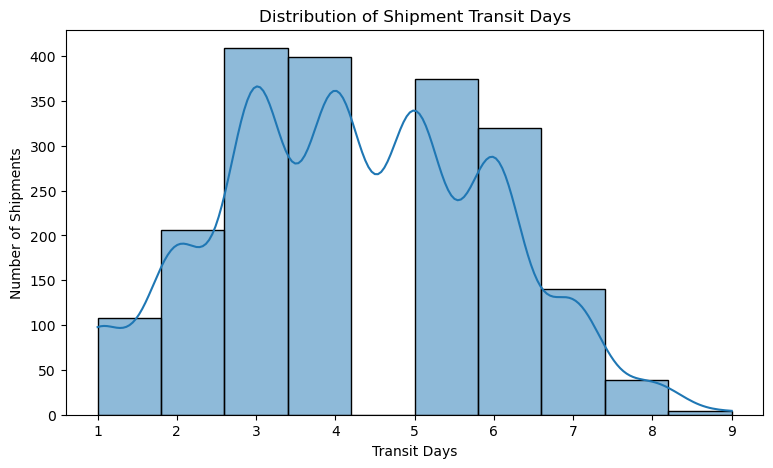

In [7]:
plt.figure(figsize=(9, 5))

sns.histplot(df["Transit_Days"], bins=10, kde=True)

plt.title("Distribution of Shipment Transit Days")
plt.xlabel("Transit Days")
plt.ylabel("Number of Shipments")

plt.show()

## 7. Feature Selection

The following variables are selected as predictors:

- Origin_Warehouse
- Destination
- Carrier
- Weight_kg
- Cost
- Distance_miles

The variables `Shipment_ID` and `Invalid_Date` are excluded because they do not provide meaningful operational information for prediction. `Delivery_Date` is excluded to prevent data leakage because it is only known after the shipment has been delivered. The target variable `Transit_Days` is also excluded from the predictor variables.

In [8]:
features = [
    "Origin_Warehouse",
    "Destination",
    "Carrier",
    "Weight_kg",
    "Cost",
    "Distance_miles"
]

target = "Transit_Days"

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Origin_Warehouse', 'Destination', 'Carrier', 'Weight_kg', 'Cost', 'Distance_miles']

Target:
Transit_Days

Feature shape: (2000, 6)
Target shape: (2000,)


## 8. Feature Type Identification

The dataset contains both numerical and categorical predictors. Numerical variables can be used directly, while categorical variables must be converted into numerical representations using one-hot encoding.

In [9]:
categorical_features = [
    "Origin_Warehouse",
    "Destination",
    "Carrier"
]

numerical_features = [
    "Weight_kg",
    "Cost",
    "Distance_miles"
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Origin_Warehouse', 'Destination', 'Carrier']

Numerical Features:
['Weight_kg', 'Cost', 'Distance_miles']


## 9. Train-Test Split

The dataset is divided into training and testing subsets. The training data is used to build the models, while the testing data is kept separate to evaluate how well the trained models perform on unseen shipment records.

An 80:20 split is used.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 1600
Testing records: 400


## 10. Data Preprocessing for Machine Learning

Categorical variables are transformed using One-Hot Encoding so that machine learning algorithms can process them numerically. Numerical variables are passed through without transformation because the selected regression models can work directly with their numerical values.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 11. Model 1 — Linear Regression

Linear Regression is used as the baseline model. It is simple, interpretable, and useful for understanding whether a linear relationship exists between the selected logistics features and transit time.

In [12]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 0.8136
RMSE: 0.9914
R²  : 0.6714


## 12. Model 2 — Decision Tree Regressor

A Decision Tree Regressor is used to capture non-linear relationships between logistics features and shipment transit time. Unlike Linear Regression, a decision tree can model threshold-based patterns and interactions between variables.

In [14]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=8
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

decision_tree_mae = mean_absolute_error(
    y_test,
    decision_tree_predictions
)

decision_tree_rmse = np.sqrt(
    mean_squared_error(y_test, decision_tree_predictions)
)

decision_tree_r2 = r2_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Results")
print("--------------------")
print("MAE :", round(decision_tree_mae, 4))
print("RMSE:", round(decision_tree_rmse, 4))
print("R²  :", round(decision_tree_r2, 4))

Decision Tree Results
--------------------
MAE : 0.9275
RMSE: 1.1557
R²  : 0.5534


## 13. Model 3 — Random Forest Regressor

Random Forest is an ensemble learning method that combines multiple decision trees. It is used to capture complex relationships while generally providing more robust predictions than a single decision tree.

In [15]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(y_test, random_forest_predictions)
)

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("--------------------")
print("MAE :", round(random_forest_mae, 4))
print("RMSE:", round(random_forest_rmse, 4))
print("R²  :", round(random_forest_r2, 4))

Random Forest Results
--------------------
MAE : 0.8379
RMSE: 1.0311
R²  : 0.6445


## 14. Model Performance Comparison

The three regression models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

- Lower MAE indicates smaller average prediction errors.
- Lower RMSE indicates fewer large prediction errors.
- Higher R² indicates that the model explains more variation in transit time.

In [16]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        decision_tree_mae,
        random_forest_mae
    ],
    "RMSE": [
        linear_rmse,
        decision_tree_rmse,
        random_forest_rmse
    ],
    "R2": [
        linear_r2,
        decision_tree_r2,
        random_forest_r2
    ]
})

model_results = model_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(model_results.round(4))

,Model,MAE,RMSE,R2
0,Linear Regression,0.8136,0.9914,0.6714
1,Random Forest,0.8379,1.0311,0.6445
2,Decision Tree,0.9275,1.1557,0.5534


## 15. Model Performance Visualization

A comparison chart is created to visually evaluate the predictive performance of the three models.

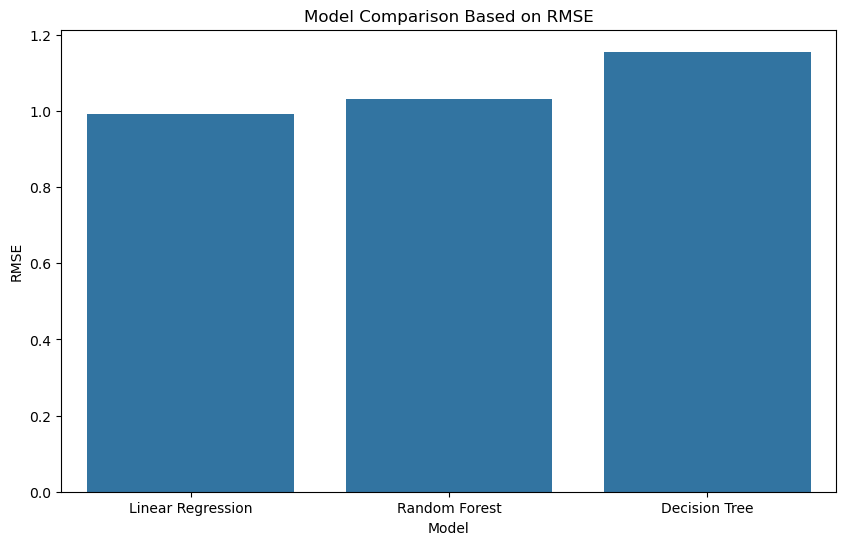

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

## 16. Cross-Validation

Five-fold cross-validation is used to evaluate the consistency of the predictive models across different subsets of the training data. This reduces dependence on a single train-test split and provides a more reliable estimate of model performance.

In [18]:
cv_scores = {}

for name, model in [
    ("Linear Regression", linear_model),
    ("Decision Tree", decision_tree_model),
    ("Random Forest", random_forest_model)
]:
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    cv_scores[name] = -scores.mean()

cv_results = pd.DataFrame(
    list(cv_scores.items()),
    columns=["Model", "CV_RMSE"]
)

cv_results = cv_results.sort_values(
    by="CV_RMSE"
).reset_index(drop=True)

display(cv_results.round(4))

,Model,CV_RMSE
0,Linear Regression,0.9645
1,Random Forest,1.0014
2,Decision Tree,1.1458


## 17. Best Model Selection

The best-performing model is selected based primarily on the lowest RMSE, while MAE and R² are also considered. Cross-validation performance is used as an additional validation check.

In [19]:
best_model_name = model_results.loc[
    model_results["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


## 18. Feature Importance Analysis

Feature importance is analyzed using the Random Forest model to identify which logistics variables contribute most to predicting shipment transit time. The results can help identify operational factors that should receive greater attention during logistics planning and optimization.

In [20]:
# Get the fitted preprocessing and Random Forest model
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]

# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance
importance_values = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(15).round(4))

,Feature,Importance
0,numerical__Distance_miles,0.8116
1,numerical__Cost,0.0504
2,numerical__Weight_kg,0.0455
3,categorical__Destination_Mumbai,0.0054
4,categorical__Carrier_Delhivery,0.0052
5,categorical__Destination_Kolkata,0.0049
6,categorical__Carrier_XpressBees,0.0044
7,categorical__Origin_Warehouse_Pune_Warehouse,0.0043
8,categorical__Origin_Warehouse_Ahmedabad_Warehouse,0.0043
9,categorical__Destination_Nashik,0.0042


## 19. Feature Importance Visualization

The most influential predictive features are visualized to make the model results easier to interpret and connect with logistics operations.

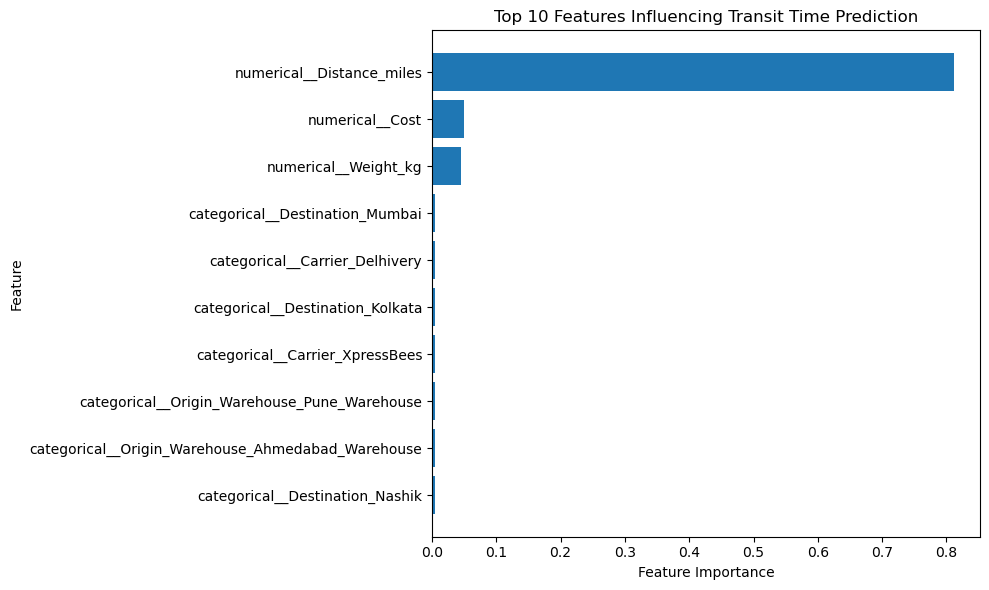

In [21]:
top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features Influencing Transit Time Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 20. Actual vs Predicted Transit Time

The actual and predicted transit times are compared to visually evaluate the predictive performance of the selected Random Forest model.

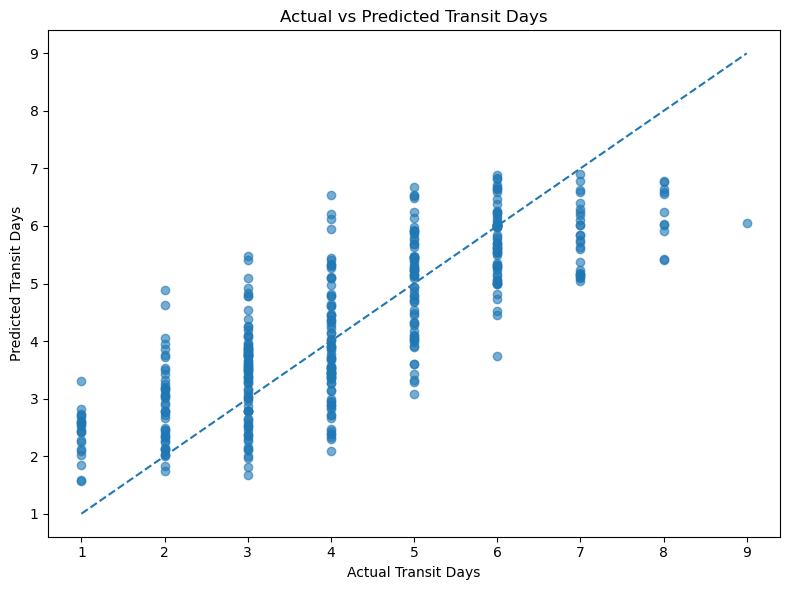

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Transit Days")
plt.xlabel("Actual Transit Days")
plt.ylabel("Predicted Transit Days")

plt.tight_layout()
plt.show()

## 21. Prediction Error Analysis

Prediction errors are calculated to identify the difference between actual and predicted transit times. This helps assess where the model performs well and where larger prediction errors may occur.

In [23]:
prediction_analysis = pd.DataFrame({
    "Actual_Transit_Days": y_test.values,
    "Predicted_Transit_Days": random_forest_predictions
})

prediction_analysis["Prediction_Error"] = (
    prediction_analysis["Actual_Transit_Days"]
    - prediction_analysis["Predicted_Transit_Days"]
)

prediction_analysis["Absolute_Error"] = (
    prediction_analysis["Prediction_Error"].abs()
)

display(
    prediction_analysis.head(10).round(2)
)

,Actual_Transit_Days,Predicted_Transit_Days,Prediction_Error,Absolute_Error
0,3,4.53,-1.53,1.53
1,3,3.88,-0.88,0.88
2,8,6.02,1.98,1.98
3,4,6.11,-2.11,2.11
4,3,2.34,0.66,0.66
5,3,3.66,-0.66,0.66
6,9,6.05,2.95,2.95
7,7,5.76,1.24,1.24
8,3,4.09,-1.09,1.09
9,4,4.77,-0.77,0.77


## 22. Largest Prediction Errors

The shipments with the largest absolute prediction errors are identified. These records can help highlight unusual shipment patterns or operational conditions that may require further investigation.

In [24]:
largest_errors = prediction_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

display(largest_errors.round(2))

,Actual_Transit_Days,Predicted_Transit_Days,Prediction_Error,Absolute_Error
6,9,6.05,2.95,2.95
83,2,4.89,-2.89,2.89
30,2,4.63,-2.63,2.63
135,8,5.42,2.58,2.58
58,8,5.43,2.57,2.57
227,4,6.55,-2.55,2.55
100,3,5.48,-2.48,2.48
293,3,5.41,-2.41,2.41
178,1,3.31,-2.31,2.31
294,6,3.74,2.26,2.26


## 23. Logistics Optimization Strategies

The predictive modeling results are translated into practical logistics optimization strategies. The recommendations are based on the observed model performance, feature importance, shipment characteristics, and prediction errors.

The objective is not only to predict transit time but also to use predictive insights to improve logistics planning, route management, carrier allocation, and proactive delay monitoring.

In [25]:
print("Optimization Insights")
print("=====================")

print("\n1. Route Planning:")
print("Prioritize efficient routes for shipments with high predicted transit times.")

print("\n2. Carrier Allocation:")
print("Use carrier performance and predicted transit time to support carrier selection.")

print("\n3. Proactive Delay Monitoring:")
print("Flag shipments with unusually high predicted transit times for early intervention.")

print("\n4. Warehouse Planning:")
print("Use predicted transit requirements to support shipment scheduling and resource planning.")

print("\n5. Cost Management:")
print("Evaluate long-distance shipments carefully because transportation distance can influence logistics cost and transit time.")

Optimization Insights

1. Route Planning:
Prioritize efficient routes for shipments with high predicted transit times.

2. Carrier Allocation:
Use carrier performance and predicted transit time to support carrier selection.

3. Proactive Delay Monitoring:
Flag shipments with unusually high predicted transit times for early intervention.

4. Warehouse Planning:
Use predicted transit requirements to support shipment scheduling and resource planning.

5. Cost Management:
Evaluate long-distance shipments carefully because transportation distance can influence logistics cost and transit time.


## 24. Data-Driven Optimization Recommendations

The following recommendations connect predictive modeling results with practical logistics decisions.

In [26]:
optimization_recommendations = pd.DataFrame({
    "Area": [
        "Route Planning",
        "Carrier Allocation",
        "Delay Monitoring",
        "Warehouse Planning",
        "Transportation Cost"
    ],
    
    "Recommendation": [
        "Prioritize efficient routes for shipments with high predicted transit times.",
        "Use predicted transit time and historical carrier performance to support carrier selection.",
        "Flag shipments with unusually high predicted transit times for proactive intervention.",
        "Use predicted delivery requirements to improve shipment scheduling and resource allocation.",
        "Monitor long-distance shipments because distance can contribute to higher transportation cost and transit time."
    ]
})

display(optimization_recommendations)

,Area,Recommendation
0,Route Planning,Prioritize efficient routes for shipments with...
1,Carrier Allocation,Use predicted transit time and historical carr...
2,Delay Monitoring,Flag shipments with unusually high predicted t...
3,Warehouse Planning,Use predicted delivery requirements to improve...
4,Transportation Cost,Monitor long-distance shipments because distan...


## 25. Final Predictive Modeling Summary

The final model performance is summarized using MAE, RMSE, and R². These metrics provide quantitative evidence of the model's ability to predict shipment transit time.

In [27]:
best_result = model_results.iloc[0]

print("FINAL MODEL SUMMARY")
print("===================")

print("Best Model:", best_result["Model"])
print("MAE:", round(best_result["MAE"], 4))
print("RMSE:", round(best_result["RMSE"], 4))
print("R²:", round(best_result["R2"], 4))

FINAL MODEL SUMMARY
Best Model: Linear Regression
MAE: 0.8136
RMSE: 0.9914
R²: 0.6714


## 26. Conclusion

The Week 4 predictive modeling analysis developed machine learning models to forecast logistics shipment transit time. Linear Regression, Decision Tree, and Random Forest models were trained and evaluated using MAE, RMSE, and R².

The models were validated using five-fold cross-validation, and their performance was compared to identify the most suitable predictive approach.

Feature importance and prediction-error analysis were then used to connect model results with logistics operations. The findings support practical optimization strategies including improved route planning, carrier allocation, proactive delay monitoring, warehouse planning, and transportation cost management.

The analysis demonstrates how predictive analytics can support data-driven logistics decision-making by providing advance estimates of shipment transit time and identifying factors that influence delivery performance.